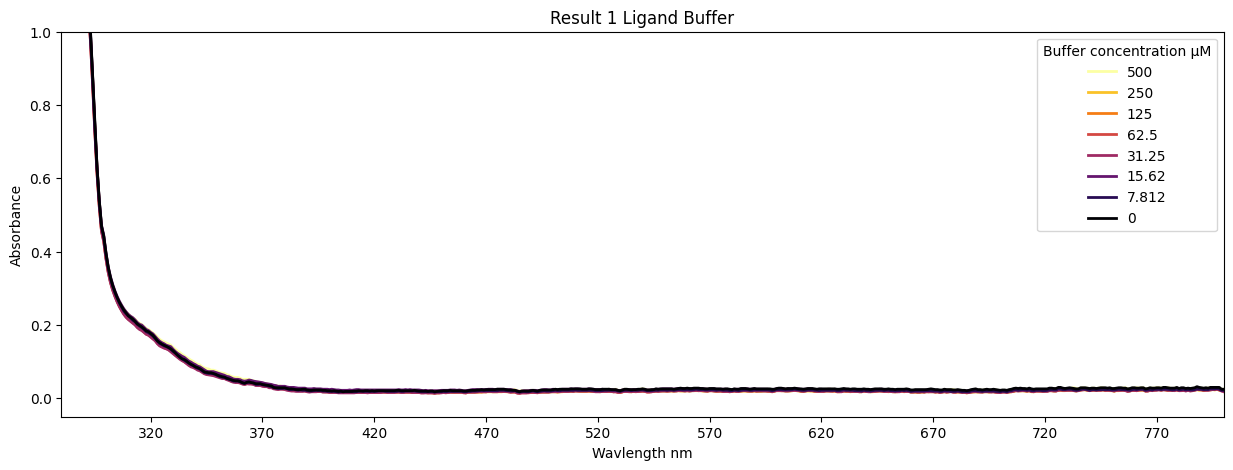

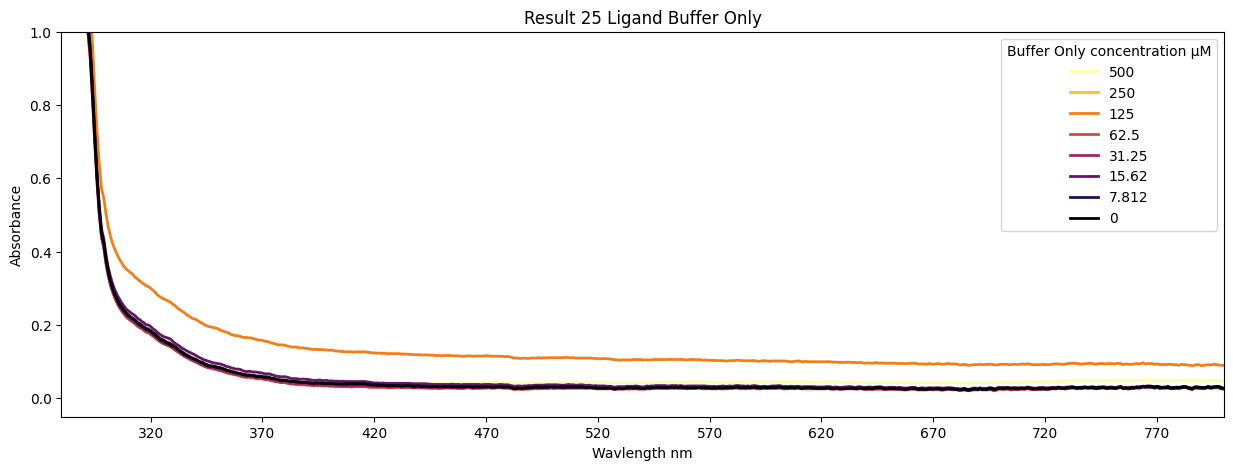

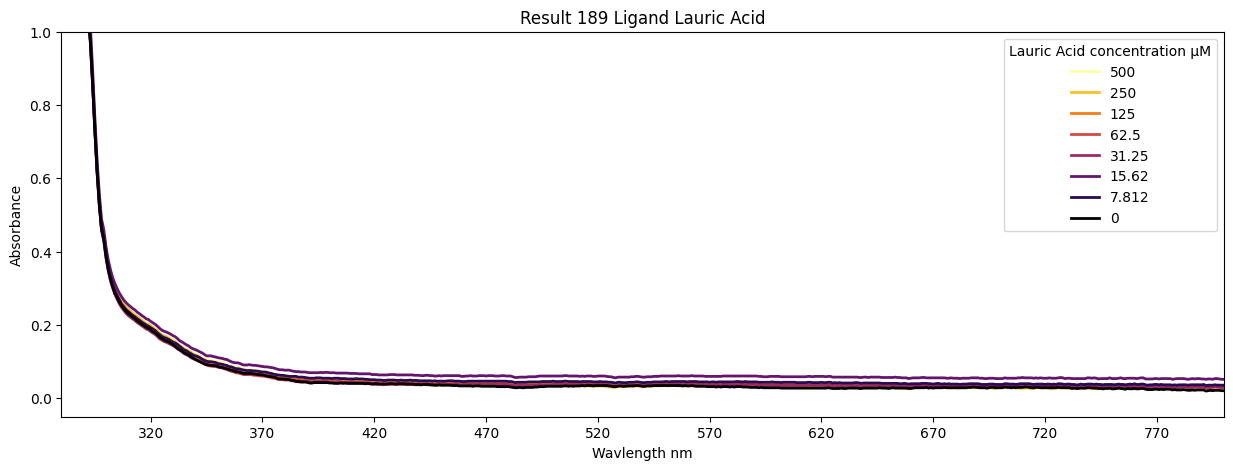

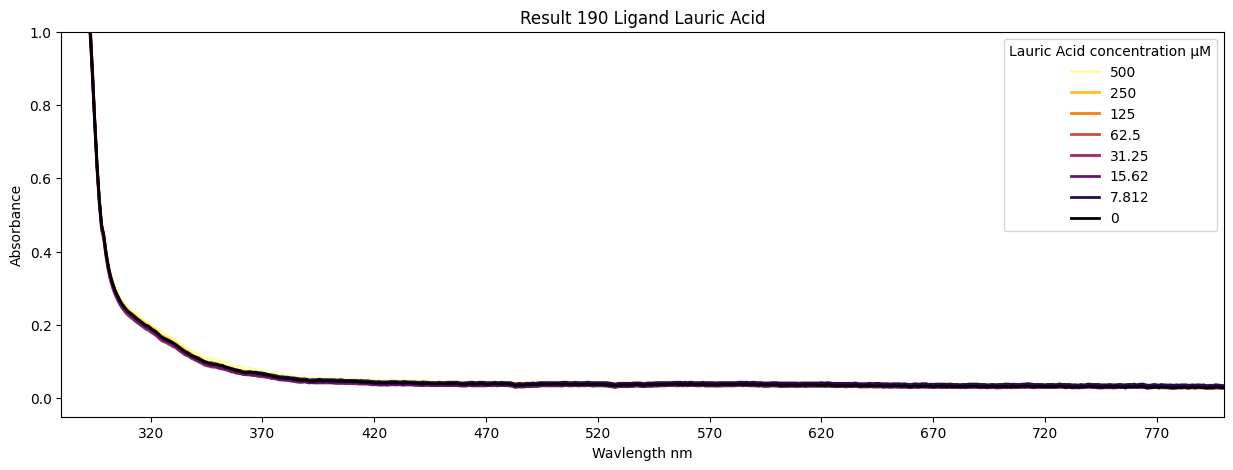

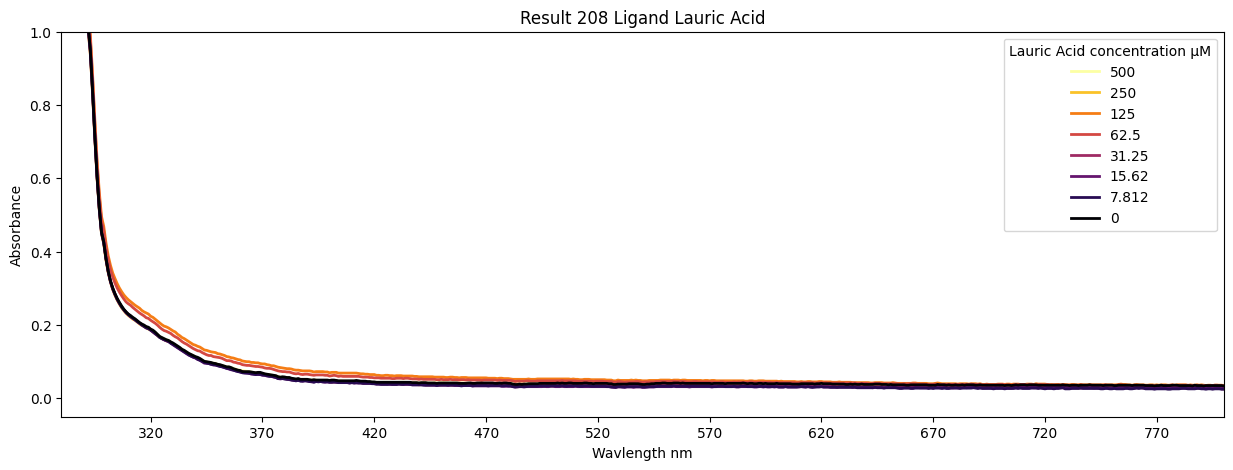

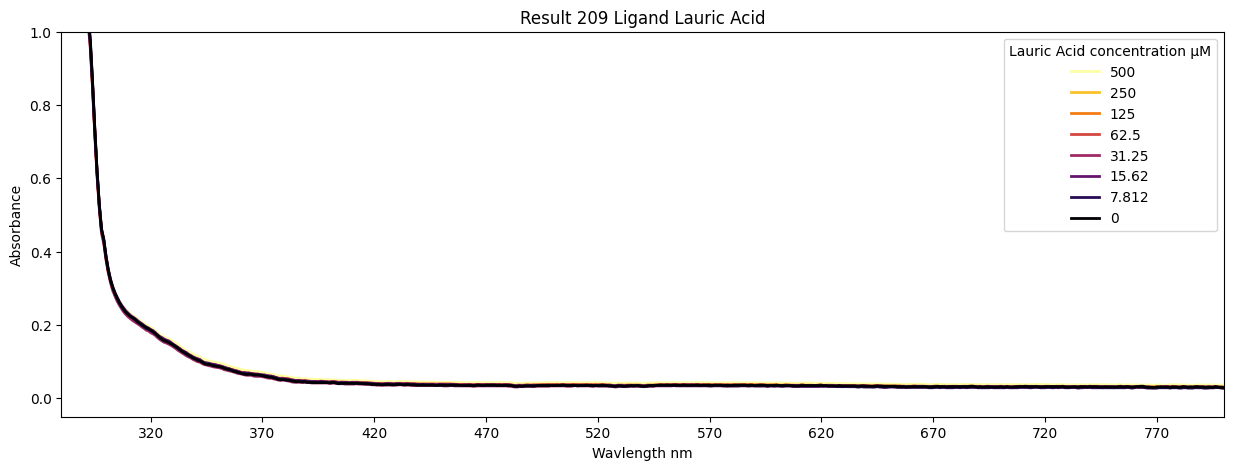

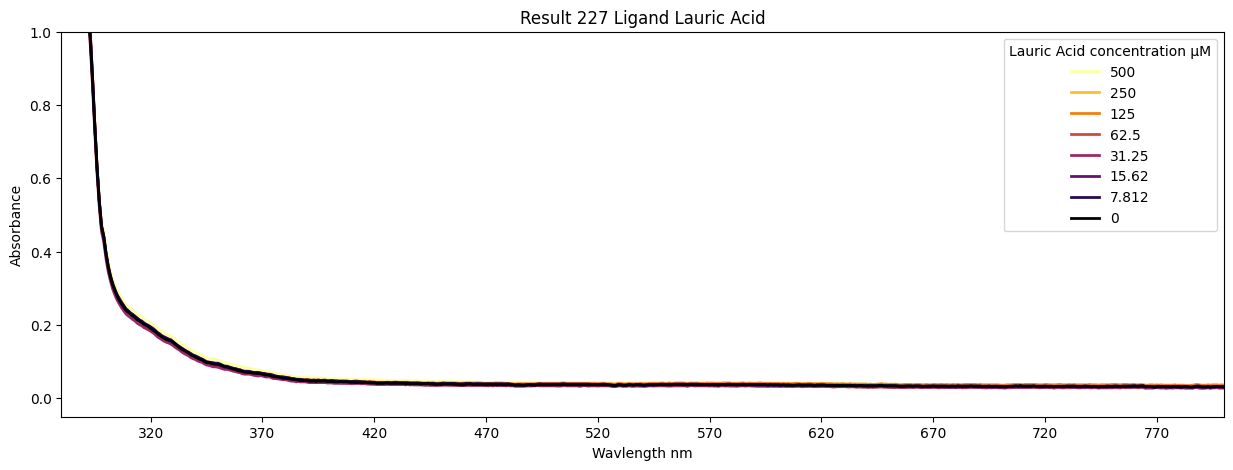

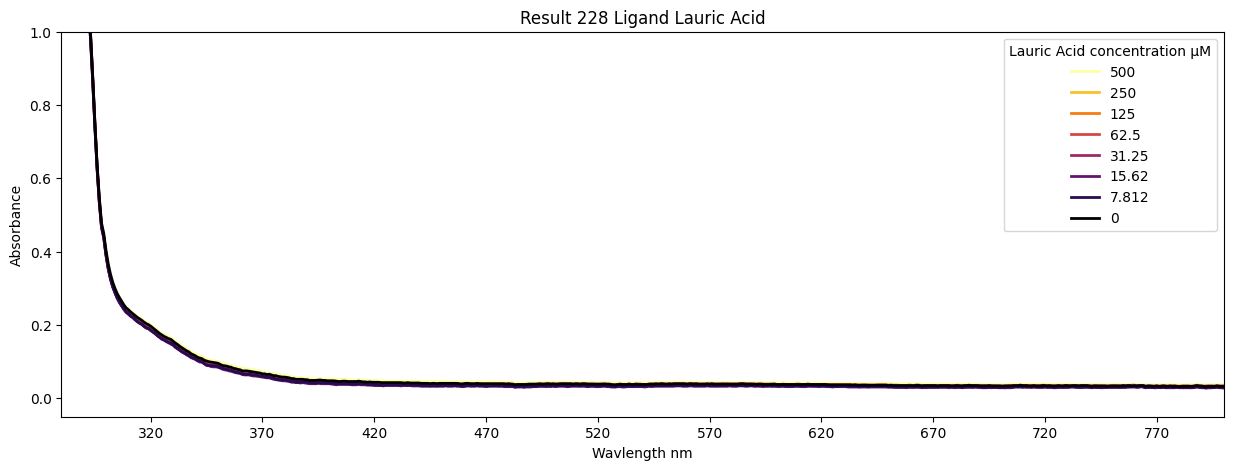

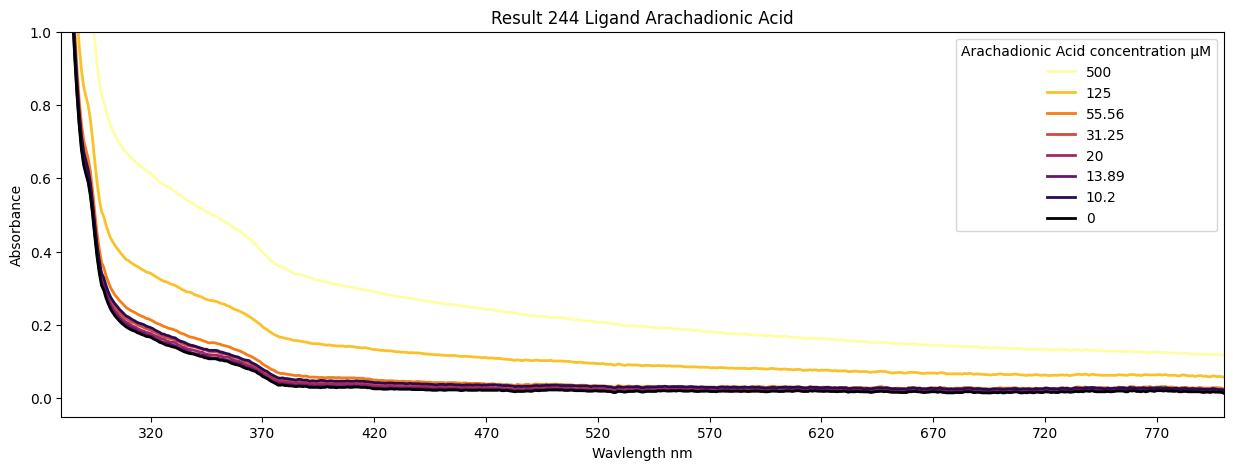

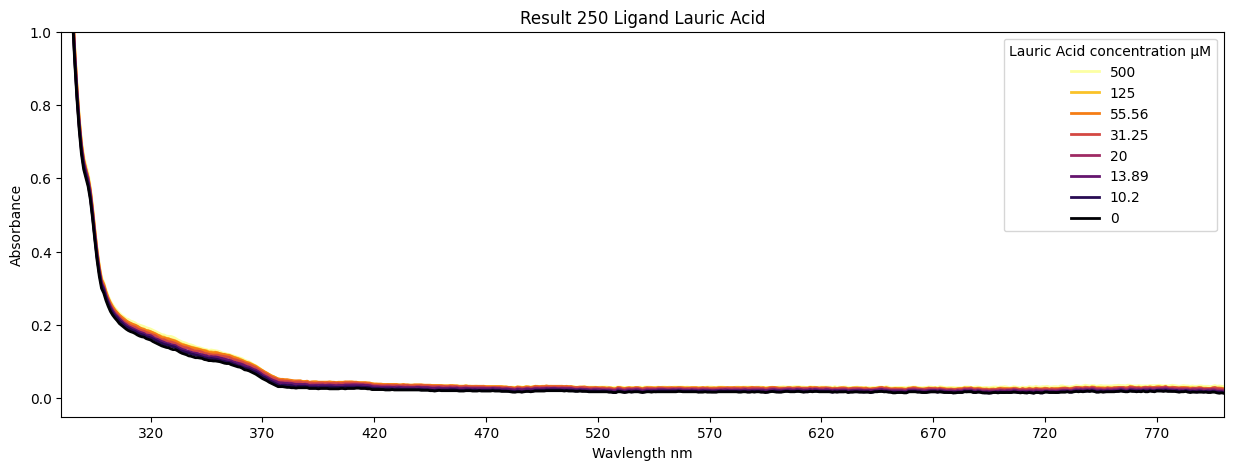

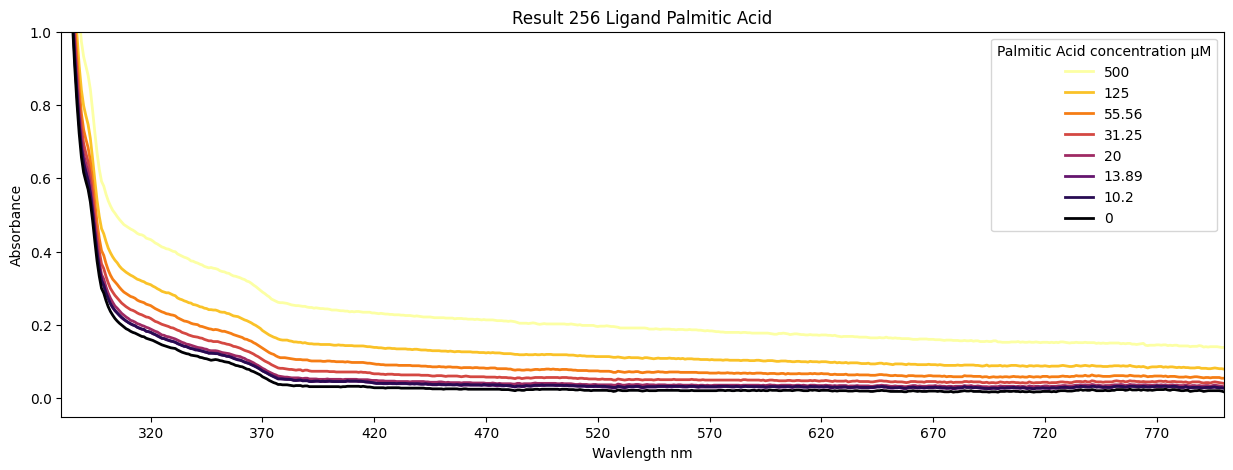

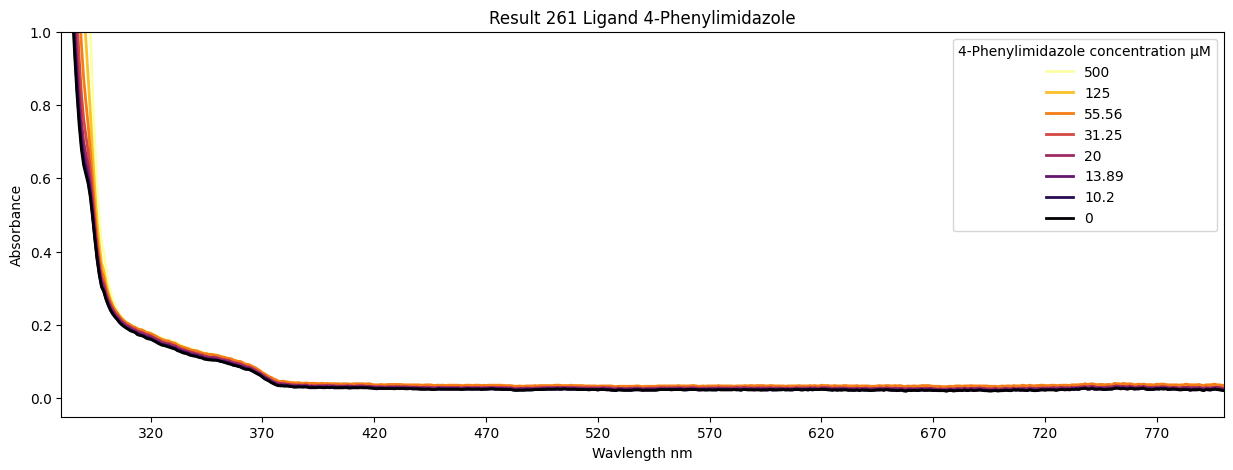

In [5]:
import os
import json
import os.path as osp
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import utils

# db_dir = osp.abspath(osp.join('..', 'db-checkpoints'))
# assert osp.exists(db_dir)
# os.listdir(db_dir)
# path = osp.join(db_dir, 'db-2024-08-17:11:04.sqlite3')

save_dir = 'mis-dispense-p450'
if not os.path.exists(save_dir):
    os.mkdir(save_dir)
    
path = osp.join('..', 'db.sqlite3')
assert osp.exists(path)

sql_query = '''SELECT w.id,
	 w.result_id,
	 a_800,
	 auc,
	 k,
	 rsq,
	 concentration,
	 volume,
	 address,
	 file,
	 ligand,
	 control,
	 w.comment as well_comment,
	 exclude,
      raw_data,
	 rc.comment as result_comment
    FROM "wells" w
    LEFT JOIN "result_comments" rc
        ON w.result_id = rc.result_id
'''

with sqlite3.connect(path) as con:
    df_ = pd.read_sql(sql_query, con)

df = df_.loc[df_['result_comment'].str.contains('no protein|mis dispense protein').astype(bool), :]

for result_id in df['result_id'].unique():
    res = df.loc[df['result_id'] == result_id, :].reset_index(drop=True)
    res_wells =  pd.json_normalize(res['raw_data'].apply(json.loads))
    res_wells_test = res_wells.loc[res['control'] == 0, :]
    res_test = res.loc[res['control'] == 0, :]
    
    ligand_name = res['ligand'].unique()[0]
    
    utils.plot.plot_plate_data(res_wells_test,
                               concs=res_test['concentration'],
                               title=f'Result {result_id} Ligand {ligand_name}',
                               ligand_name=ligand_name,
                              )
    save_path = os.path.join(save_dir, 
                          f'result-{result_id}-ligand-{ligand_name.lower().replace(" ", "-")}.png'
                         )
    plt.savefig(save_path)
    plt.show()

In [2]:
res = df.loc[df['result_id'] == result_id, :]
res_wells =  pd.json_normalize(res['raw_data'].apply(json.loads))
res_test = res.loc[res['control'] == 0, :]
#res_wells_test = res_wells.loc[res['control'] == 0, :]
res_wells

,220,221,222,223,224,225,226,227,228,229,...,791,792,793,794,795,796,797,798,799,800
0,2.069,2.236,2.166,2.697,2.566,2.737,2.614,2.901,3.500,3.500,...,0.034,0.035,0.034,0.033,0.033,0.034,0.034,0.034,0.034,0.033
1,3.500,2.299,2.011,2.648,2.987,2.806,2.622,2.686,3.500,3.500,...,0.031,0.032,0.032,0.032,0.033,0.034,0.033,0.033,0.031,0.030
2,3.500,2.378,2.236,3.500,3.500,3.500,2.986,2.803,3.500,3.216,...,0.035,0.037,0.037,0.037,0.038,0.039,0.037,0.037,0.036,0.035
3,3.500,3.500,3.005,3.500,2.725,2.488,2.447,2.810,3.184,3.099,...,0.028,0.030,0.029,0.029,0.030,0.031,0.030,0.029,0.028,0.026
4,2.474,2.635,3.106,2.696,2.746,3.500,2.918,2.669,3.003,2.828,...,0.027,0.029,0.028,0.028,0.029,0.030,0.030,0.030,0.028,0.026
5,2.520,2.309,2.016,2.529,2.624,2.913,2.648,3.250,3.093,3.004,...,0.023,0.025,0.026,0.025,0.026,0.027,0.025,0.024,0.024,0.022
6,2.527,2.819,2.588,2.445,2.825,3.500,2.941,3.373,3.500,2.944,...,0.022,0.024,0.024,0.023,0.024,0.026,0.025,0.025,0.023,0.022
7,2.694,2.546,2.534,3.500,3.156,3.500,3.500,3.160,3.500,3.500,...,0.021,0.024,0.023,0.023,0.024,0.025,0.024,0.023,0.022,0.021
8,2.033,1.922,2.098,3.278,2.247,2.417,2.453,2.638,2.743,2.880,...,0.033,0.033,0.033,0.032,0.034,0.034,0.033,0.034,0.032,0.031
9,2.385,2.126,2.441,2.626,2.504,2.600,2.440,2.775,3.319,2.738,...,0.030,0.031,0.031,0.031,0.032,0.033,0.031,0.032,0.031,0.029
